In [ ]:
import pdfplumber as pdf
import requests
import pandas as pd
import io
import re
from collections import Counter
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\55119\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Questão 1- Análise de Frequência de Palavras em um PDF Acadêmico

Pegue um artigo acadêmico em formato PDF. Seu objetivo é analisar o conteúdo textual do artigo e identificar as 10 palavras mais frequentes, desconsiderando palavras comuns da língua portuguesa (stopwords), como "de", "a", "o", "e", etc.
Tarefas:
1. Leia o conteúdo textual do PDF.
2. Limpe o texto, removendo pontuações e convertendo tudo para letras minúsculas.
3. Remova as stopwords da língua portuguesa.
4. Conte a frequência de cada palavra restante.
5. Exiba as 10 palavras mais frequentes e suas respectivas contagens.

Desafio Extra (opcional):
1. Gere uma nuvem de palavras (word cloud) com as palavras mais frequentes usando a biblioteca wordcloud.

### Solução Antiga

In [ ]:
artigo_path = r"https://raw.githubusercontent.com/joaopedro-peres/Sueste-Capital/b485a752e120ea8c9798035e32325313abf82f0d/Adriano%20Pitt%20Dall%E2%80%99Agnol_.pdf"
response = requests.get(artigo_path)
artigo_file = io.BytesIO(response.content)

In [ ]:
import pdfplumber as pdf

texto_completo = ""

try:
    with pdf.open(artigo_file) as pdf:
        for pagina in pdf.pages:
            texto_pagina = pagina.extract_text()
            if texto_pagina:
                texto_completo += texto_pagina + "\n"

except Exception as e:
    print(f"Erro ao ler o PDF: {e}")

texto_completo = texto_completo.lower()

# 2. Define o padrão para "caçar" só palavras (ignora números e pontuação)
padrao_palavras = r'\b[a-záéíóúâêôãõç]+\b'

# 3. Cria a LISTA DE PALAVRAS (o passo mais importante!)
# O findall vai varrer a string e retornar ['adriano', 'pitt', 'dall', 'agnol', ... ]
palavras = re.findall(padrao_palavras, texto_completo)
    

In [ ]:
stop_words = nltk.corpus.stopwords.words('portuguese')

#==============================
# Problema: o loop anterior le tudo, inclusive rodapé, sumário, índices, tabelas,..
# Impacto: pode "suja" a análise de palavaras que mais aparecem

# Solução: Adiconar palavras 'comuns' na lista de stop wrods para serem removidas tb...
#==============================

stop_words.extend([
    "página", "artigo", "revista", "trabalho", "estudo", "apud",
    "gráfico", "tabela", "anexo", "apêndice", "figura",
    "introdução", "conclusão", "resultados", "metodologia",
    "referências", "bibliográficas", "capítulo", "seção", "sobre",
    "ser", "ter", "para", "como", "assim", "dessa", "desse",
    "neste", "nesta", "pode", "pdf", "isbn", "ano"
])

texto_sem_stopwords = [
    palavra for palavra in palavras if palavra not in stop_words
]

contagem_palavras = Counter(texto_sem_stopwords)

# most_common(10) dá a lista das 10 palvras que mais aparecem

top_10 = contagem_palavras.most_common(10)
df_top10 = pd.DataFrame(top_10, columns=['Palavra', 'Frequência'])
df_top10

### Solução Nova

In [7]:
import pdfplumber

caminho_do_arquivo = r"C:\Users\55119\Downloads\Adriano Pitt Dall’Agnol_.pdf" 

texto_completo = ""

try:
    with pdfplumber.open(caminho_do_arquivo) as pdf:
        
        for pagina in pdf.pages:
            texto_extraido = pagina.extract_text()
            if texto_extraido:
                texto_completo += texto_extraido + "\n"

    if texto_completo:
        texto_completo = texto_completo.lower()
        
        palavras = re.findall(r'\b[a-záéíóúâêôãõç]+\b', texto_completo)
        # Stopwords
        stop_words = nltk.corpus.stopwords.words('portuguese')
        stop_words_extras = [
            "página", "artigo", "revista", "trabalho", "estudo", "apud",
            "gráfico", "tabela", "anexo", "apêndice", "figura", "introdução",
            "conclusão", "resultados", "metodologia", "referências", "bibliográficas",
            "capítulo", "seção", "sobre", "ser", "ter", "para", "como", "assim",
            "dessa", "desse", "neste", "nesta", "pode", "pdf", "isbn", "ano", "universidade"
        ]
        stop_words.extend(stop_words_extras)
        
        # Filtragem
        palavras_filtradas = [p for p in palavras if p not in stop_words and len(p) > 2]
        contagem = Counter(palavras_filtradas)
        df_top10 = pd.DataFrame(contagem.most_common(10), columns=['Palavra', 'Frequência'])
        
        print("\n--- TOP 10 PALAVRAS ---")
        display(df_top10)
    else:
        print("Aviso: Nenhum texto foi extraído do PDF")

except FileNotFoundError:
    print(f"O arquivo não foi encontrado no caminho: {caminho_do_arquivo}")
    print("Verifique se o nome e a pasta estão corretos.")
except Exception as e:
    print(f"Ocorreu um erro ao processar o PDF: {e}")


--- TOP 10 PALAVRAS ---


,Palavra,Frequência
0,presença,193
1,estratégia,124
2,tecnologias,106
3,visão,100
4,fintechs,95
5,digitais,95
6,pagamentos,87
7,experimentação,82
8,impacto,75
9,importância,75


## Questão 2. Extração de dados CCB e Cálculo Valor Presente

Extraia as seguintes informações da CCB: 
1. CPF 
2. nome completo
3. número da proposta
4. data de nascimento
5. primeiro vencimento
6. último vencimento
7. valor da parcela
8. quantidade de parcelas
9. taxa de juros mensal.

 Utilize essas informações para chegar no valor presente do contrato. A taxa de desconto deve ser a taxa de juros mensal.

### Solução Antiga

In [ ]:
""" Ler o arquivo publuico no github"""

ccb_path = r"https://raw.githubusercontent.com/joaopedro-peres/Sueste-Capital/fb4bfcb86cbe6c73dc5d807e56ab02d856bcb51a/CCB.pdf"
response = requests.get(ccb_path)
ccb_file = io.BytesIO(response.content)

""" Variáveis auxiliares """

dados = {} # dicionário p/ armazenar dados do doc

# Padrões Regex para cada campo


padroes = {
    "cpf": r"CPF:\s*(\d{3}\.\d{3}\.\d{3}-\d{2})",
    "nome": r"Nome:(.*?)\n", # Captura tudo até a próxima linha
    "proposta": r"CÉDULA DE CRÉDITO BANCÁRIO Nº\s*([\d\-]+)",
    "data_nascimento": r"Data Nascimento:\s*(\d{2}/\d{2}/\d{4})",
    "primeiro_vencimento": r"1º Vencimento:\s*(\d{2}/\d{2}/\d{4})",
    "ultimo_vencimento": r"Último Vencimento:\s*(\d{2}/\d{2}/\d{4})",
    "valor_parcela": r"Valor da Parcela:\s*([\d\.,]+)",
    "qtd_parcelas": r"Quantidade de Parcelas:\s*(\d+)",
    "taxa_juros": r"Taxa de Juros mensal:\s*([\d\.,]+)\s*%" # Mais flexível com espaços (\s*)
}


''' Ler pagína 1 do ccb'''

with pdf.open(ccb_file) as ccb:    
    ''' Todas as infos estão na página 1 ([0)]) '''
    texto = ccb.pages[0].extract_text()


''' MAIN '''

for chave, padrao in padroes.items():
    
    match = re.search(padrao, texto)
    
    if match:
        dados[chave] = match.group(1).strip()  #pega o primeiro grupo [1] (o que estava entre parênteses) e remove espaços extras
        # print(dados[chave])
    else: dados[chave] = None


''' arrumando o type '''
try: 
    valor_parcela = float(dados["valor_parcela"].replace(".", "").replace(",", ".")) # "2.696,95" -> "2696,95" -> "2696.95" -> 2696.95
    qtd_parcelas = int(dados["qtd_parcelas"])
    taxa = float(dados["taxa_juros"].replace(",", ".").replace(",", ".")) # "1,80" -> "1.80" -> 1.80
    taxa = round(taxa / 100, 5)  # percentual

except(ValueError, TypeError, AttributeError) as e:

    print(f"\nErro ao converter dados para cálculo: {e}")
    print("Verifique se todos os dados foram extraídos corretamente.")
    pass

''' CÁLCULO VP'''

valor_presente = valor_parcela * ( (1 - ( (1 + taxa)**(-qtd_parcelas) ) ) / taxa ) 
valor_presente = round(valor_presente, 2)

print(f"""
Taxa de Juros: {taxa}
Valor parcela: {valor_parcela}
Qtd parcelas: {qtd_parcelas}
      """)
print(f"VP =  valor_parcela * ( (1 - [ (1 + taxa)^(-qtd_parcelas)]) / taxa)")
print(f"VP =  {valor_parcela} * (( 1 - [ (1 + {taxa})^(-{qtd_parcelas})]) / {taxa} )")
print(f"\nValor presente: {valor_presente}")

### Solução Nova

In [ ]:
caminho_ccb = r"C:\Users\55119\Downloads\CCB.pdf"
dados_extraidos = {}

try:
    
    with pdfplumber.open(caminho_ccb) as pdf:
        primeira_pagina = pdf.pages[0]
        texto_ccb = primeira_pagina.extract_text()

    if texto_ccb:
        # EXTRAÇÃO VIA REGEX
        # Regex insensível a maiúsculas/minúsculas
        mapeamento_campos = {
            "cpf": r"CPF:?\s*(\d{3}\.\d{3}\.\d{3}-\d{2})",
            "nome": r"Nome:?\s*(.+?)\n", 
            "proposta": r"CÉDULA DE CRÉDITO BANCÁRIO Nº\s*([\d\-]+)",
            "valor_parcela": r"Valor da Parcela:?\s*([\d\.,]+)",
            "qtd_parcelas": r"Quantidade de Parcelas:?\s*(\d+)",
            "taxa_juros": r"Taxa de Juros mensal:?\s*([\d\.,]+)\s*%"
        }

        for chave, padrao in mapeamento_campos.items():
            match = re.search(padrao, texto_ccb, re.IGNORECASE)
            if match:
                dados_extraidos[chave] = match.group(1).strip()
            else:
                dados_extraidos[chave] = None
        
        # --- CÁLCULOS FINANCEIROS ---
       
        try:
            if dados_extraidos["valor_parcela"] and dados_extraidos["taxa_juros"]:
                # Remove ponto de milhar e troca vírgula decimal por ponto
                str_parcela = dados_extraidos["valor_parcela"].replace(".", "").replace(",", ".")
                str_taxa = dados_extraidos["taxa_juros"].replace(",", ".")
                
                valor_parcela = float(str_parcela)
                qtd_parcelas = int(dados_extraidos["qtd_parcelas"])
                taxa_mensal = float(str_taxa) / 100 
                
                # Fórmula do VP
                fator_vp = (1 - (1 + taxa_mensal) ** (-qtd_parcelas)) / taxa_mensal
                valor_presente = valor_parcela * fator_vp
                
                print("\n" + "="*40)
                print("            RESUMO DO CONTRATO")
                print("="*40)
                print(f"Nome:           {dados_extraidos['nome']}")
                print(f"CPF:            {dados_extraidos['cpf']}")
                print(f"Nº Proposta:    {dados_extraidos['proposta']}")
                print("-" * 40)
                print(f"Parcelas:       {qtd_parcelas} x R$ {valor_parcela:,.2f}")
                print(f"Taxa Mensal:    {taxa_mensal * 100:.2f}%")
                print("-" * 40)
                print(f"VALOR PRESENTE (VP): R$ {valor_presente:,.2f}")
                print("="*40)
            else:
                print("Erro: Não foi possível encontrar valor da parcela ou taxa no PDF.")
                
        except ValueError:
            print("Erro ao converter valores monetários. Verifique o formato no PDF.")

    else:
        print("O arquivo PDF parece estar vazio ou é uma imagem sem texto OCR.")

except FileNotFoundError:
    print(f"ERRO: O arquivo '{caminho_ccb}' não foi encontrado. Verifique o caminho.")
except Exception as e:
    print(f"Erro inesperado: {e}")


            RESUMO DO CONTRATO
Nome:           ANA MARIA CORREA BARBOSA
CPF:            209.816.942-68
Nº Proposta:    802046333-0
----------------------------------------
Parcelas:       96 x R$ 2,696.95
Taxa Mensal:    1.80%
----------------------------------------
VALOR PRESENTE (VP): R$ 122,802.57


## Questão 3 - Análise de Pedidos de Clientes

Escreva uma consulta SQL que retorne o nome dos clientes cujo valor total em pedidos é maior que a média geral de valor dos pedidos de sua cidade (isto é, a média do campo valor_total dos pedidos).

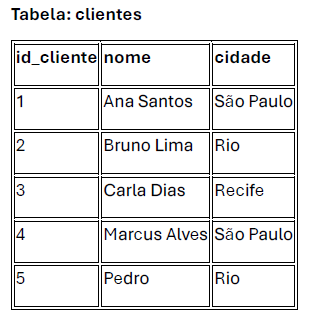 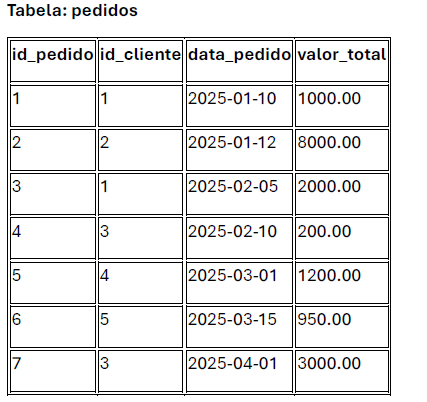


In [ ]:
import sqlite3


print("\n--- RESOLUÇÃO QUESTÃO 3 (SQL) ---")

# 1. "Planilhar" os valores (Criar dados Mockados para teste)
dados_clientes = {
    'id_cliente': [1, 2, 3, 4, 5],
    'nome': ['  Ana Santos', 'Bruno Lima', 'Carlos Dias', 'Marcus Alves', 'Pedro'],
    'cidade': ['São Paulo', 'Rio', 'Recife', 'São Paulo', 'Rio']
}

dados_pedidos = {
    'id_pedido': [1, 2, 3, 4, 5, 6, 7],
    'id_cliente': [1, 2, 1, 3, 4, 5,3], 
    'valor_total': [1000, 8000, 2000,200,1200,950,3000],
    'data_pedido': [2025-1-10, 2025-1-12, 2025-2-5, 2025-2-10, 2023-3-1, 2025-3-15, 2025-4-1] 
}

df_clientes = pd.DataFrame(dados_clientes)
df_pedidos = pd.DataFrame(dados_pedidos)

# Criar Banco de Dados rodar o SQL (na memória)
conn = sqlite3.connect(':memory:')
df_clientes.to_sql('clientes', conn, index=False)
df_pedidos.to_sql('pedidos', conn, index=False)

# 3. A Query SQL Corrigida (String no meio do código)
# CTE 1: Gasto total POR CLIENTE.
# CTE 2: Média de valor POR PEDIDO agrupado por cidade (join clientes e pedidos).

query_sql = """
WITH Gasto_Total_Cliente AS (
    -- Quanto cada cliente gastou no total (soma de seus pedidos)
    SELECT 
        p.id_cliente,
        c.nome,
        c.cidade,
        SUM(p.valor_total) as total_gasto_cliente
    FROM pedidos p
    JOIN clientes c ON p.id_cliente = c.id_cliente
    GROUP BY p.id_cliente, c.nome, c.cidade
),

Media_Pedidos_Cidade AS (
    SELECT 
        c.cidade,
        AVG(p.valor_total) as media_valor_pedidos_cidade
    FROM pedidos p
    JOIN clientes c ON p.id_cliente = c.id_cliente
    GROUP BY c.cidade
)

SELECT 
    gtc.nome AS Nome_Cliente,
    gtc.cidade AS Cidade,
    gtc.total_gasto_cliente AS Valor_Total_Cliente,
    mpc.media_valor_pedidos_cidade AS Media_Pedidos_Da_Cidade
FROM 
    Gasto_Total_Cliente gtc
JOIN 
    Media_Pedidos_Cidade mpc ON gtc.cidade = mpc.cidade
WHERE 
    gtc.total_gasto_cliente > mpc.media_valor_pedidos_cidade
ORDER BY 
    gtc.cidade, gtc.nome;
"""

resultado = pd.read_sql_query(query_sql, conn)

print("\n--- Resultado ---")
display(resultado)



--- RESOLUÇÃO QUESTÃO 3 (SQL) ---

--- Resultado ---


,Nome_Cliente,Cidade,Valor_Total_Cliente,Media_Pedidos_Da_Cidade
0,Carlos Dias,Recife,3200,1600.0
1,Bruno Lima,Rio,8000,4475.0
2,Ana Santos,São Paulo,3000,1400.0
